# Fetch planets' positions relative to ESMUC

In [2]:
!pip3 install ephem


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



https://rhodesmill.org/pyephem/quick
https://rhodesmill.org/pyephem/radec
https://rhodesmill.org/pyephem/tutorial.html

In [1]:
def pretty(d, indent=0):
   for key, value in d.items():
      print('\t' * indent + str(key))
      if isinstance(value, dict):
         pretty(value, indent+1)
      else:
         print('\t' * (indent+1) + str(value))

## Get data

In [2]:
import ephem

planets = [
    ephem.Moon(),
    ephem.Mercury(),
    ephem.Venus(),
    ephem.Mars(),
    ephem.Jupiter(),
    ephem.Saturn(),
    ephem.Uranus()
]



measurings = dict.fromkeys((planet.name for planet in planets), {}) # Initialize dictionary

# Set up observing point
observer = ephem.Observer()
observer.name = "ESMUC"
observer.lat = '41.39858935189999'
observer.lon = '2.1853450576007365'
observer.elevation = 18  # meters
observer.pressure = 0


startingDate = ephem.Date('2001/12/06 05:00')
observer.date = startingDate - 2 * ephem.hour # ephem works with UTC. This accounts for the timezone

rangDies = 365 * 25 + 6 # days that the simulation will run
stepHores = 24 * 365 # how many hours are stepped
print((24 * rangDies) / (stepHores)) # number of iterations that will run

iterations = 0

while(iterations < (24 * rangDies) / (stepHores)):
    for _, planet in enumerate(planets):
        planet.compute(observer)
        dateValues = dict({
            str(observer.date): {
                'separation': ephem.separation(observer, planet), 
                'mag': planet.mag, 
                'size': planet.size, 
                'alt': planet.alt, 
                'az': planet.az,
                'earth_distance': planet.earth_distance * 1000
                }
            })
            
        measurings[planet.name] =  {**measurings[planet.name], **dateValues}
        
    iterations += 1
    observer.date += stepHores * ephem.hour

print(iterations)
pretty((measurings))


25.016438356164382
26
Moon
	2001/12/6 03:00:00
		separation
			111:44:28.6
		mag
			-11.06
		size
			1967.6387939453125
		alt
			59:03:27.1
		az
			132:10:51.6
		earth_distance
			2.438570139929652
	2002/12/6 03:00:00
		separation
			102:08:25.2
		mag
			-6.39
		size
			1896.1414794921875
		alt
			-65:41:36.5
		az
			58:04:40.3
		earth_distance
			2.530519850552082
	2003/12/6 03:00:00
		separation
			42:43:24.6
		mag
			-11.84
		size
			1777.98388671875
		alt
			16:48:39.5
		az
			275:20:27.3
		earth_distance
			2.69868690520525
	2004/12/5 03:00:00
		separation
			127:42:36.9
		mag
			-10.19
		size
			1838.834716796875
		alt
			38:12:00.5
		az
			115:07:33.7
		earth_distance
			2.6093823835253716
	2005/12/5 03:00:00
		separation
			86:16:34.7
		mag
			-8.21
		size
			1921.9208984375
		alt
			-73:44:51.8
		az
			354:31:31.8
		earth_distance
			2.4965773336589336
	2006/12/5 03:00:00
		separation
			57:36:35.5
		mag
			-12.68
		size
			1955.35107421875
		alt
			47:24:43.8
		az
			266:26:1

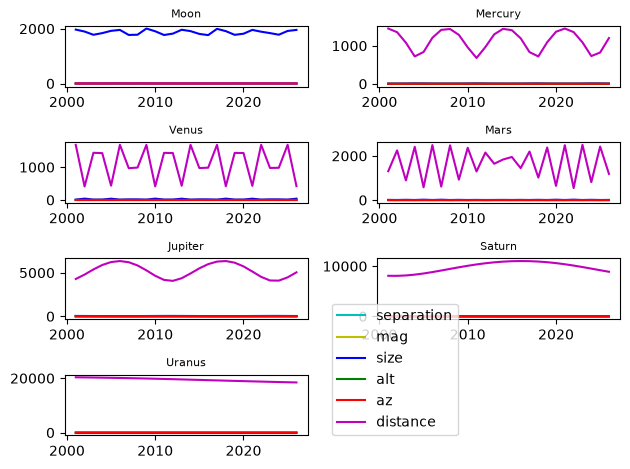

<class 'dict'>


In [ ]:
import matplotlib.pylab as plt
import numpy as np

xAxis = np.linspace(2001, 2026, int(iterations)) # TODO: NO FORÇAR EL RANG
planetsArray = {}

for j, planet in enumerate(planets):
    values = {'separation': {}, 'mag': {}, 'size': {}, 'alt': {}, 'az': {}, 'distance': {}}

    for i in range(len(measurings[planet.name])):
        values["separation"][i] = list(measurings[planet.name].values())[i]["separation"]
        values["mag"][i] = list(measurings[planet.name].values())[i]["mag"]
        values["size"][i] = list(measurings[planet.name].values())[i]["size"]
        values["alt"][i] = list(measurings[planet.name].values())[i]["alt"]
        values["az"][i] = list(measurings[planet.name].values())[i]["az"]
        values["distance"][i] = list(measurings[planet.name].values())[i]["earth_distance"]

    # pretty(values)

    planetsArray[planet.name] = values

    ax = plt.subplot(4, 2, j+1)
    
    ax.plot(xAxis, values["separation"].values(), 'c', label="separation")
    ax.plot(xAxis, values["mag"].values(), 'y', label="mag")
    ax.plot(xAxis, values["size"].values(), 'b', label="size")
    ax.plot(xAxis, values["alt"].values(), 'g', label="alt")
    ax.plot(xAxis, values["az"].values(), 'r', label="az")
    ax.plot(xAxis, values["distance"].values(), 'm', label="distance")
    ax.set_title(planet.name, fontsize=8)


plt.tight_layout()
plt.legend(loc=(1.1,0))
plt.show()

## Get planets within viewing scope

Good tools to check if calculations are correct: https://stellarium-web.org/, https://heavens-above.com/

In [6]:
# Using azalts

viewing_angle = ephem.degrees("20:00:00.0") # Minimum azimuth to consider a planet visible (higher az = higher in the sky)

visiblePlanets = {}

for j in range(len(measurings["Moon"])):
    visiblePlanetsAtThisTime = {}

    for i, planet in enumerate(planets):
        thisPlanet = list(measurings[planet.name].values())[j]

        if(thisPlanet['alt'] > viewing_angle):
            time = list(measurings[planet.name].keys())[j]
            # print('%s is visible from %s at %s with %s degrees separation' % (planet.name, observer.name, time, separation))
            visiblePlanetsAtThisTime[planet.name] = {
                'separation': thisPlanet['separation'], 
                'mag': thisPlanet['mag'],
                'size': thisPlanet['size'], 
                'alt': thisPlanet['alt'],
                'az': thisPlanet['az'], 
                'distance': thisPlanet['earth_distance'], 
                'time': time.split(" ")[1]
            }
    if(visiblePlanetsAtThisTime):
     visiblePlanets[time] = {**visiblePlanetsAtThisTime}

pretty(visiblePlanets)


2001/12/6 03:00:00
	Moon
		separation
			111:44:28.6
		mag
			-11.06
		size
			1967.6387939453125
		alt
			59:03:27.1
		az
			132:10:51.6
		distance
			2.438570139929652
		time
			03:00:00
	Jupiter
		separation
			84:14:19.8
		mag
			-2.5
		size
			45.93256378173828
		alt
			66:24:41.8
		az
			222:38:31.5
		distance
			4283.236026763916
		time
			03:00:00
	Saturn
		separation
			60:20:00.2
		mag
			-0.4
		size
			20.49083137512207
		alt
			41:21:55.2
		az
			260:45:22.5
		distance
			8081.663131713867
		time
			03:00:00
2002/12/6 03:00:00
	Jupiter
		separation
			110:57:32.0
		mag
			-2.18
		size
			41.06669235229492
		alt
			59:53:29.1
		az
			141:46:57.7
		distance
			4790.743827819824
		time
			03:00:00
	Saturn
		separation
			71:19:58.2
		mag
			-0.4
		size
			20.513683319091797
		alt
			54:25:39.9
		az
			248:10:48.4
		distance
			8072.660446166992
		time
			03:00:00
2003/12/6 03:00:00
	Jupiter
		separation
			131:11:18.7
		mag
			-1.88
		size
			36.58457565307617
		alt
			34:59:5

In [12]:
sel = "Jupiter"
sel = measurings[sel]
monitor = 'earth_distance'
vals = []
for i in range(len(sel)):
    vals.append(list(sel.values())[i][monitor])

print(min(vals), max(vals))


4068.868637084961 6340.6243324279785


# Fent servir OSC

In [8]:
!pip3 install python-osc


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [7]:
from pythonosc import udp_client
import time as t
from datetime import datetime
import math

client = udp_client.SimpleUDPClient("127.0.0.1", 5050, timeout=10)

In [8]:
duration_s = 60 * 2
data_points = len(visiblePlanets)
print(data_points)
timeInterval = duration_s/data_points
print(timeInterval)

21
5.714285714285714


In [11]:
client.send_message("/timeInterval", timeInterval)


for i, date in enumerate(visiblePlanets):
        planetsVisibleNow = visiblePlanets[date]

        outMessages = []

        for i, planet in enumerate(planetsVisibleNow):
            planetInfo = planetsVisibleNow[planet]
            print(planet, planetInfo)

            message = (
                "/"+planet, [
                    planetInfo['separation'],
                    planetInfo['mag'],
                    planetInfo['size'],
                    planetInfo['alt'],
                    planetInfo['az'],
                    planetInfo['distance'],
                    planetInfo['time']
                ]
            )
            outMessages.append(message)

        # print(notes_on, notes_off)
        for message in outMessages:
            # print('Sending message', message)
            client.send_message(*message)
        t.sleep(timeInterval)

client.send_message("/globalMute", 0)



Moon {'separation': 1.9502530108973442, 'mag': -11.06, 'size': 1967.6387939453125, 'alt': 1.0307483673095703, 'az': 2.3069934844970703, 'distance': 2.438570139929652, 'time': '03:00:00'}
Jupiter {'separation': 1.4702450709065098, 'mag': -2.5, 'size': 45.93256378173828, 'alt': 1.1591013669967651, 'az': 3.8858375549316406, 'distance': 4283.236026763916, 'time': '03:00:00'}
Saturn {'separation': 1.0530164678098668, 'mag': -0.4, 'size': 20.49083137512207, 'alt': 0.7219612002372742, 'az': 4.551054954528809, 'distance': 8081.663131713867, 'time': '03:00:00'}
Jupiter {'separation': 1.9365981488213366, 'mag': -2.18, 'size': 41.06669235229492, 'alt': 1.0453022718429565, 'az': 2.4745748043060303, 'distance': 4790.743827819824, 'time': '03:00:00'}
Saturn {'separation': 1.244992971991982, 'mag': -0.4, 'size': 20.513683319091797, 'alt': 0.9499433636665344, 'az': 4.331560134887695, 'distance': 8072.660446166992, 'time': '03:00:00'}
Jupiter {'separation': 2.289671660031764, 'mag': -1.88, 'size': 36.5